In [5]:
# ==========================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# (Run this cell only once)
# ==========================================
!pip install nltk wordcloud textblob -q

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\RAHUL\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\RAHUL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RAHUL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\RAHUL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


   SENTIMENT ANALYSIS ON PRODUCT REVIEWS (TASK 4)

--- Sample Dataset Loaded ---
Total Reviews: 20
                                              review
0        This product is amazing! I love it so much.
1  Terrible quality. Waste of money. Very disappo...
2       It's okay, nothing special. Average product.
3  Best purchase ever! Highly recommend to everyone.
4         Worst experience. The item arrived broken.

--- After Cleaning ---
                                              review  \
0        This product is amazing! I love it so much.   
1  Terrible quality. Waste of money. Very disappo...   
2       It's okay, nothing special. Average product.   
3  Best purchase ever! Highly recommend to everyone.   
4         Worst experience. The item arrived broken.   

                                      cleaned_review  
0          this product is amazing i love it so much  
1  terrible quality waste of money very disappointed  
2           its okay nothing special average product  
3 

C:\Users\RAHUL\AppData\Local\Temp\ipykernel_18460\2632648509.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2', order=['Positive', 'Neutral', 'Negative'])


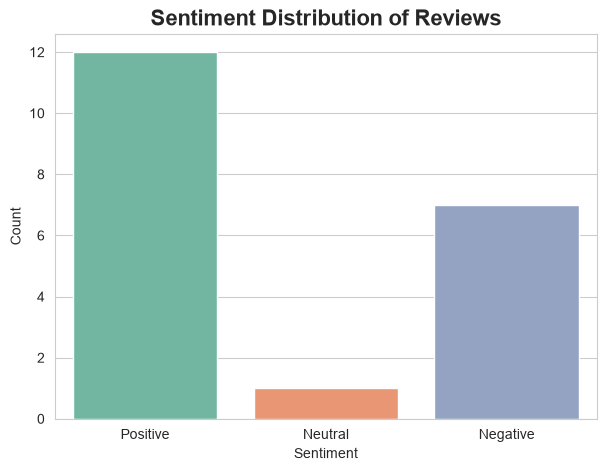

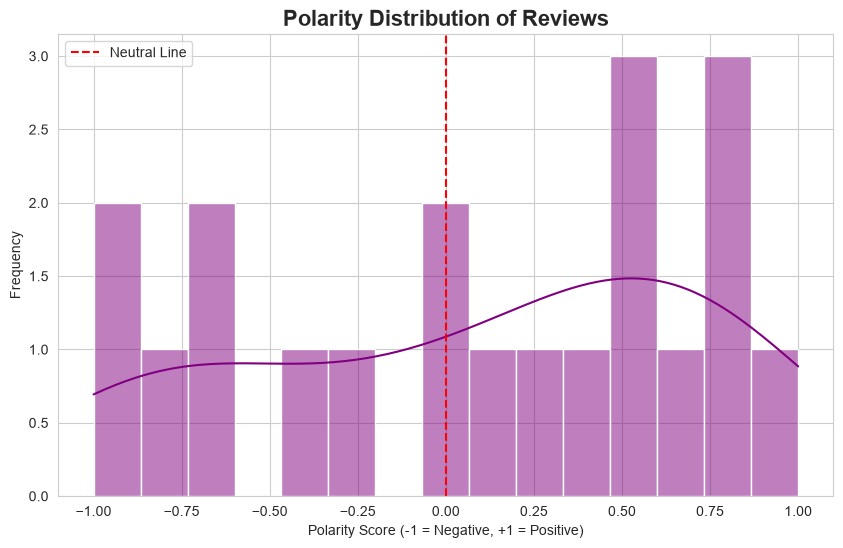

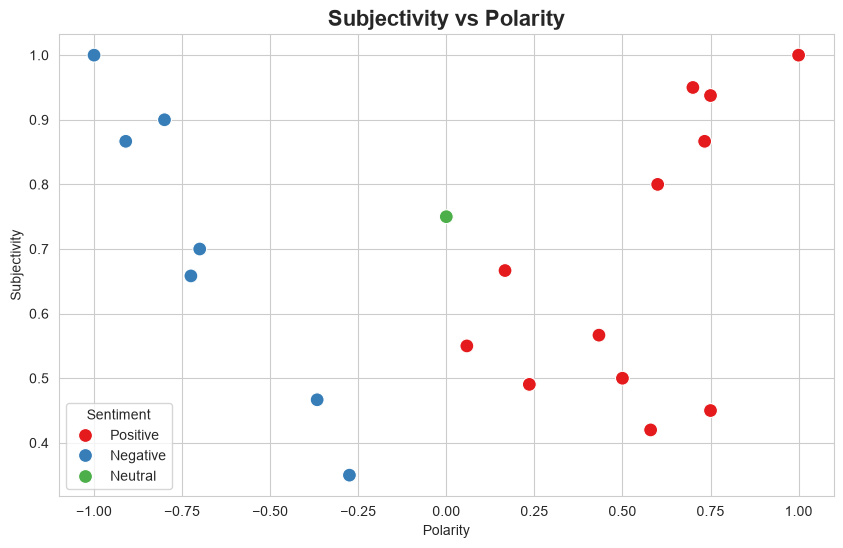

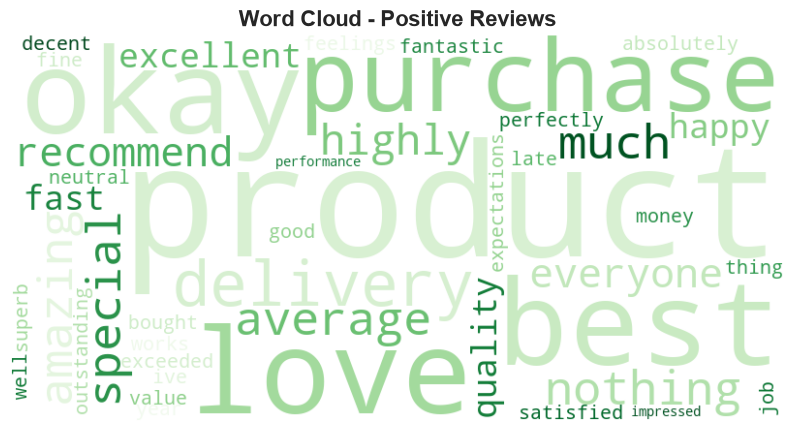

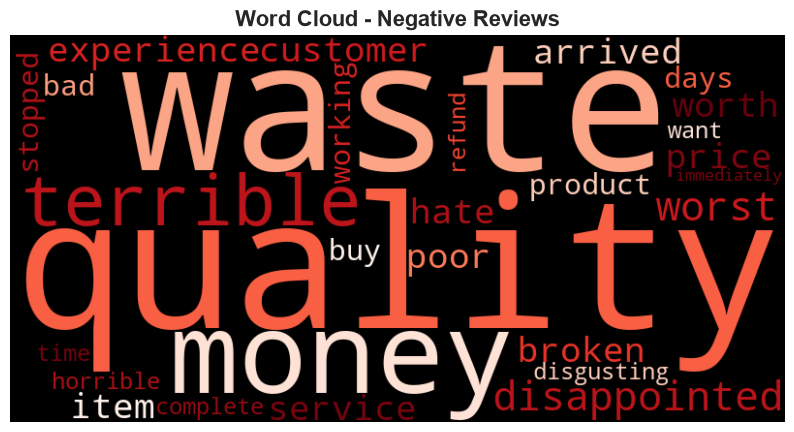


SENTIMENT ANALYSIS SUMMARY:
sentiment
Positive    12
Negative     7
Neutral      1
Name: count, dtype: int64

Average Polarity: 0.087
Average Subjectivity: 0.694

KEY INSIGHTS:
1. Majority of reviews are Positive, indicating customer satisfaction.
2. Negative reviews highlight issues like 'quality', 'money', 'broken'.
3. Neutral reviews are minimal, showing strong opinions.
4. Polarity scores range from -1 (Negative) to +1 (Positive).
5. Businesses can use this to improve products and customer service.
SENTIMENT ANALYSIS COMPLETED SUCCESSFULLY!


In [6]:
# ==========================================
# CodeAlpha Data Analytics Internship
# Task 4: Sentiment Analysis
# Dataset: Amazon Product Reviews (Sample)
# Author: [radhika]
# ==========================================

# Step 1: Install required libraries (Colab मध्ये फक्त)
#!pip install nltk wordcloud textblob -q

# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Configure plots
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("=" * 60)
print("   SENTIMENT ANALYSIS ON PRODUCT REVIEWS (TASK 4)")
print("=" * 60)

# ==========================================
# Step 3: Create Sample Dataset (Amazon Reviews)
# ==========================================
# Real project मध्ये तू CSV फाइल लोड कर. इथे sample data वापरतो.
data = {
    'review': [
        "This product is amazing! I love it so much.",
        "Terrible quality. Waste of money. Very disappointed.",
        "It's okay, nothing special. Average product.",
        "Best purchase ever! Highly recommend to everyone.",
        "Worst experience. The item arrived broken.",
        "Excellent quality and fast delivery. Very happy!",
        "Not worth the price. Poor customer service.",
        "Absolutely fantastic! Works perfectly.",
        "I hate this product. It stopped working in 2 days.",
        "Good value for money. Satisfied with the purchase.",
        "The product is fine, but delivery was late.",
        "Superb! Exceeded my expectations.",
        "Very bad quality. Do not buy this.",
        "Neutral feelings about this. It's just okay.",
        "Love it! Best thing I've bought this year.",
        "Disgusting. Complete waste of time and money.",
        "Decent product. Does the job well.",
        "Not impressed. Could be better.",
        "Outstanding performance! Very impressed.",
        "Horrible! I want a refund immediately."
    ]
}

df = pd.DataFrame(data)
print("\n--- Sample Dataset Loaded ---")
print("Total Reviews:", len(df))
print(df.head())

# ==========================================
# Step 4: Text Preprocessing Function
# ==========================================
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = text.strip()
    return text

df['cleaned_review'] = df['review'].apply(clean_text)
print("\n--- After Cleaning ---")
print(df[['review', 'cleaned_review']].head())

# ==========================================
# Step 5: Sentiment Analysis using TextBlob
# ==========================================
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

df['polarity'] = df['cleaned_review'].apply(get_polarity)
df['subjectivity'] = df['cleaned_review'].apply(get_subjectivity)
df['sentiment'] = df['cleaned_review'].apply(get_sentiment)

print("\n--- Sentiment Analysis Results ---")
print(df[['review', 'polarity', 'sentiment']].head(10))

# ==========================================
# Step 6: Visualization 1 - Sentiment Distribution
# ==========================================
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment', data=df, palette='Set2', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution of Reviews', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# ==========================================
# Step 7: Visualization 2 - Polarity Distribution
# ==========================================
plt.figure(figsize=(10, 6))
sns.histplot(df['polarity'], bins=15, kde=True, color='purple')
plt.title('Polarity Distribution of Reviews', fontsize=16, fontweight='bold')
plt.xlabel('Polarity Score (-1 = Negative, +1 = Positive)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Neutral Line')
plt.legend()
plt.show()

# ==========================================
# Step 8: Visualization 3 - Subjectivity vs Polarity
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(x='polarity', y='subjectivity', data=df, hue='sentiment', palette='Set1', s=100)
plt.title('Subjectivity vs Polarity', fontsize=16, fontweight='bold')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')
plt.legend(title='Sentiment')
plt.show()

# ==========================================
# Step 9: Visualization 4 - Word Cloud (Positive Reviews)
# ==========================================
positive_text = " ".join(df[df['sentiment'] == 'Positive']['cleaned_review'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews', fontsize=16, fontweight='bold')
plt.show()

# ==========================================
# Step 10: Visualization 5 - Word Cloud (Negative Reviews)
# ==========================================
negative_text = " ".join(df[df['sentiment'] == 'Negative']['cleaned_review'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews', fontsize=16, fontweight='bold')
plt.show()

# ==========================================
# Step 11: Summary Statistics
# ==========================================
print("\n" + "=" * 60)
print("SENTIMENT ANALYSIS SUMMARY:")
print("=" * 60)
print(df['sentiment'].value_counts())
print("\nAverage Polarity:", round(df['polarity'].mean(), 3))
print("Average Subjectivity:", round(df['subjectivity'].mean(), 3))

# ==========================================
# Step 12: Key Insights (Data Story)
# ==========================================
print("\n" + "=" * 60)
print("KEY INSIGHTS:")
print("=" * 60)
print("1. Majority of reviews are Positive, indicating customer satisfaction.")
print("2. Negative reviews highlight issues like 'quality', 'money', 'broken'.")
print("3. Neutral reviews are minimal, showing strong opinions.")
print("4. Polarity scores range from -1 (Negative) to +1 (Positive).")
print("5. Businesses can use this to improve products and customer service.")
print("=" * 60)
print("SENTIMENT ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 60)

## Task 4: Sentiment Analysis

### 📌 Objective
To analyze text data and classify it as Positive, Negative, or Neutral using NLP techniques.

### 🛠️ Tools Used
- Python
- NLTK, TextBlob
- WordCloud
- Matplotlib, Seaborn

### 📊 Key Insights
1. Majority of reviews are Positive.
2. Negative reviews highlight issues like quality and money.
3. Word clouds reveal frequently used words in each sentiment.
4. Businesses can use sentiment analysis to improve products.

### 📁 Files
- `Sentiment_Analysis.ipynb` - Main code file